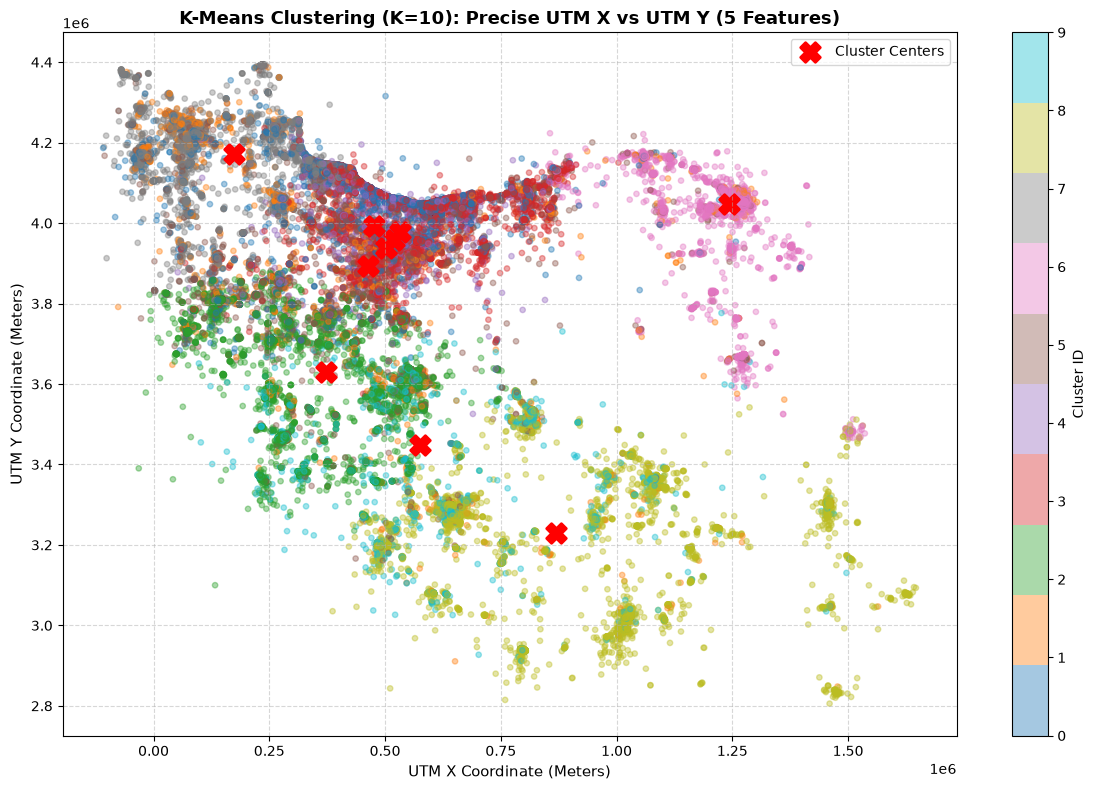

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
# ---------------------------------------------------------
# ۱. خواندن و پاک‌سازی داده‌ها
# ---------------------------------------------------------
file_path = "Divar (1).csv"
df = pd.read_csv(file_path, low_memory=False)

# آماده‌سازی متغیرها
room_mapping = {'بدون اتاق': 0, 'یک': 1, 'دو': 2, 'سه': 3, 'چهار': 4, 'پنج': 5}
df['rooms_count'] = df['rooms_count'].map(room_mapping).fillna(df['rooms_count'])
df['rooms_count'] = pd.to_numeric(df['rooms_count'], errors='coerce')
df['building_size'] = pd.to_numeric(df['building_size'], errors='coerce')
df['location_latitude'] = pd.to_numeric(df['location_latitude'], errors='coerce')
df['location_longitude'] = pd.to_numeric(df['location_longitude'], errors='coerce')
df['final_price'] = pd.to_numeric(df['price_value'], errors='coerce')

# فیلتر مختصات معتبر
df_clean = df[
    (df['location_latitude'] > 25) & (df['location_latitude'] < 40) &
    (df['location_longitude'] > 44) & (df['location_longitude'] < 64)
].copy()

# فیلتر قیمت و متراژ معتبر
df_clean = df_clean[
    (df_clean['final_price'] > 10000000) & 
    (df_clean['building_size'] >= 15) & 
    (df_clean['building_size'] <= 3000)
].copy()

# حذف پرت‌های قیمتی
q_low = df_clean['final_price'].quantile(0.01)
q_high = df_clean['final_price'].quantile(0.98)
df_clean = df_clean[(df_clean['final_price'] >= q_low) & (df_clean['final_price'] <= q_high)]

# تبدیل UTM
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)
df_clean['utm_x'], df_clean['utm_y'] = transformer.transform(
    df_clean['location_longitude'].values,
    df_clean['location_latitude'].values
)

# انتخاب ۵ ویژگی و اِعمال تبدیل لوگاریتمی
features = ['utm_x', 'utm_y', 'final_price', 'building_size', 'rooms_count']
X = df_clean[features].dropna().copy()

X['final_price_log'] = np.log1p(X['final_price'])
X['building_size_log'] = np.log1p(X['building_size'])

features_model = ['utm_x', 'utm_y', 'final_price_log', 'building_size_log', 'rooms_count']
X_model = X[features_model]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

# ---------------------------------------------------------
# ۲. اجرای اولیه K-Means (K=10) و رسم اسکترپلات UTM
# ---------------------------------------------------------
kmeans_10 = KMeans(n_clusters=10, random_state=42, n_init=10)
X['cluster_10'] = kmeans_10.fit_predict(X_scaled)

centers_scaled_10 = kmeans_10.cluster_centers_
centers_original_10 = scaler.inverse_transform(centers_scaled_10)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X['utm_x'], X['utm_y'],
    c=X['cluster_10'], cmap='tab10',
    alpha=0.4, s=15
)

plt.scatter(
    centers_original_10[:, 0], centers_original_10[:, 1],
    c='red', marker='X', s=200, linewidths=2, label='Cluster Centers'
)

plt.title('K-Means Clustering (K=10): Precise UTM X vs UTM Y (5 Features)', fontsize=13, fontweight='bold')
plt.xlabel('UTM X Coordinate (Meters)', fontsize=11)
plt.ylabel('UTM Y Coordinate (Meters)', fontsize=11)
plt.colorbar(scatter, label='Cluster ID')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

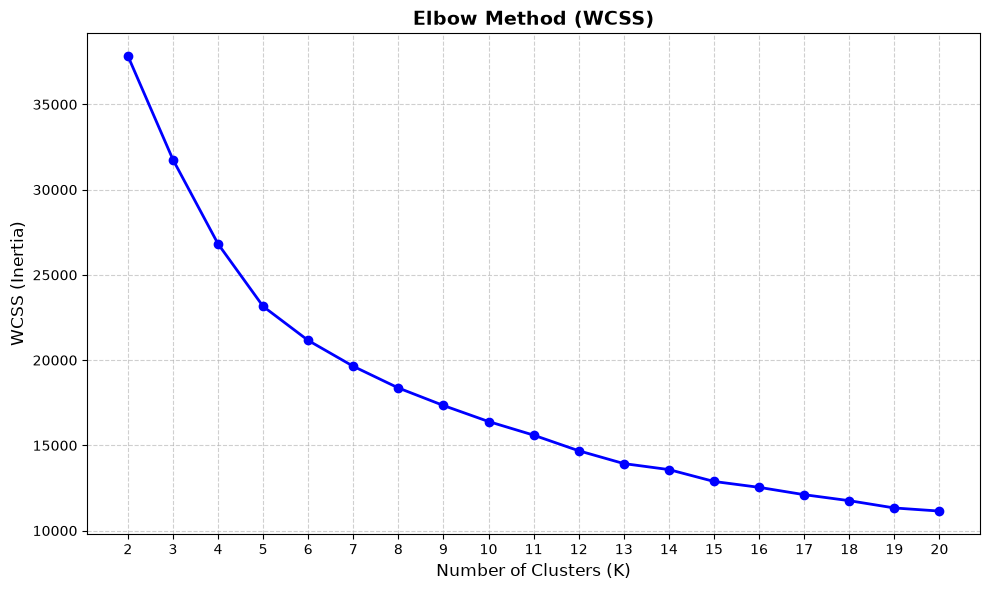

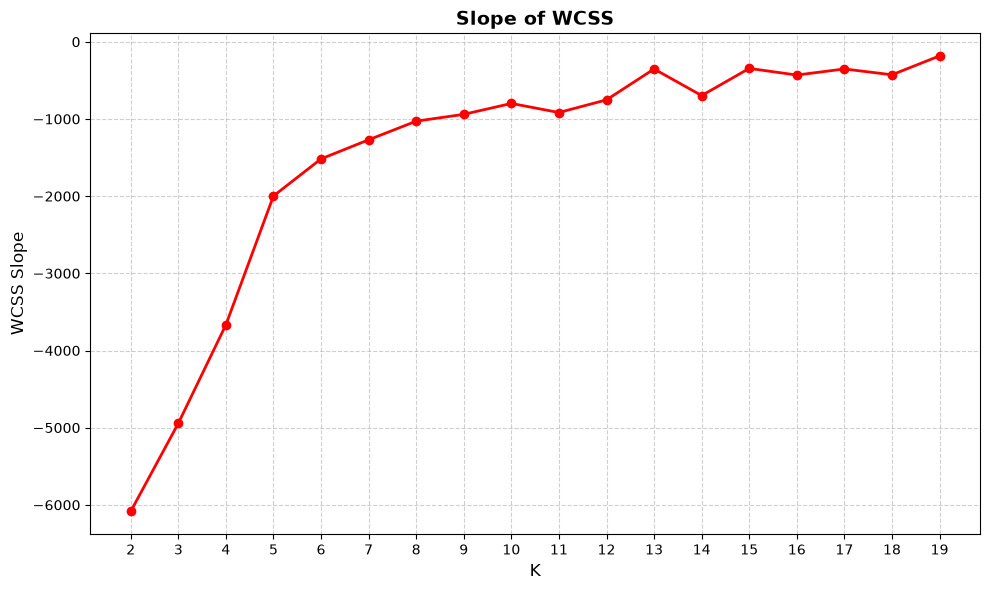

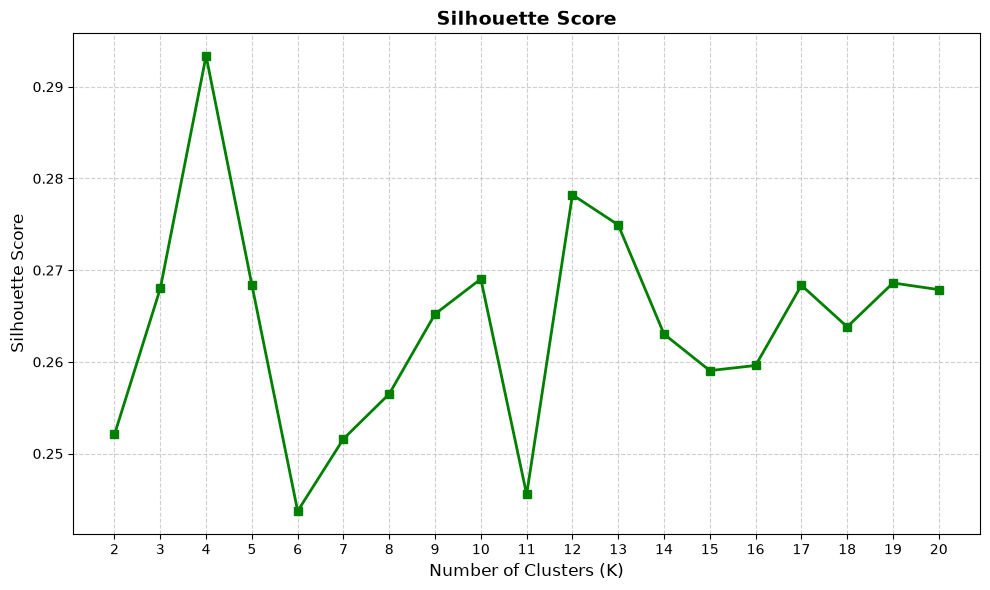

In [9]:
from sklearn.metrics import silhouette_score

# ---------------------------------------------------------
# ۱. نمونه‌گیری جهت محاسبه سریع WCSS و Silhouette
# ---------------------------------------------------------
np.random.seed(42)

sample_size = min(10000, X_scaled.shape[0])
sample_indices = np.random.choice(
    X_scaled.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

wcss = []
silhouette_scores = []

k_range = range(2, 21)

# ---------------------------------------------------------
# ۲. محاسبه شاخص‌ها برای K بین ۲ تا ۲۰
# ---------------------------------------------------------
for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_sample)

    # WCSS
    wcss.append(kmeans.inertia_)

    # Silhouette Score
    silhouette_scores.append(
        silhouette_score(X_sample, cluster_labels)
    )

# ---------------------------------------------------------
# ۳. محاسبه شیب WCSS بین Kهای متوالی
# ---------------------------------------------------------
wcss_slopes = []

k_values = list(k_range)

for i in range(len(wcss) - 1):

    slope = wcss[i + 1] - wcss[i]

    wcss_slopes.append(slope)

# K مربوط به هر شیب
# مثلاً شیب بین K=2 و K=3 با K=2 نمایش داده می‌شود
slope_k = k_values[:-1]


# ---------------------------------------------------------
# ۴. نمودار اول: Elbow Method (WCSS)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    wcss,
    marker='o',
    linestyle='-',
    color='b',
    linewidth=2
)

plt.title(
    'Elbow Method (WCSS)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Clusters (K)',
    fontsize=12
)

plt.ylabel(
    'WCSS (Inertia)',
    fontsize=12
)

plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# ۵. نمودار دوم: شیب WCSS
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    slope_k,
    wcss_slopes,
    marker='o',
    linestyle='-',
    color='r',
    linewidth=2
)

plt.title(
    'Slope of WCSS',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'K',
    fontsize=12
)

plt.ylabel(
    'WCSS Slope',
    fontsize=12
)

plt.xticks(slope_k)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# ۶. نمودار سوم: Silhouette Score
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker='s',
    linestyle='-',
    color='g',
    linewidth=2
)

plt.title(
    'Silhouette Score',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Clusters (K)',
    fontsize=12
)

plt.ylabel(
    'Silhouette Score',
    fontsize=12
)

plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

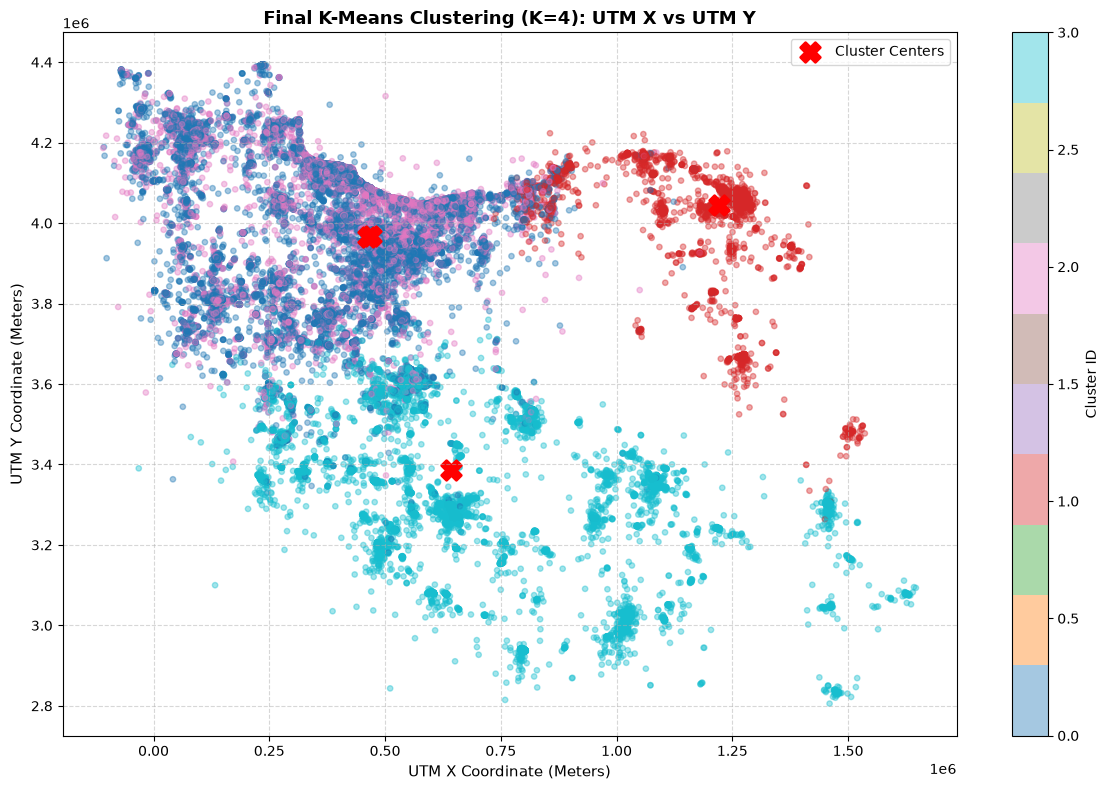

In [11]:
# ---------------------------------------------------------
# ۱. اجرای K-Means نهایی با K=4 روی کل داده‌ها
# ---------------------------------------------------------
k_optimal = 4

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
X['cluster_final'] = kmeans_final.fit_predict(X_scaled)

# مراكز خوشه‌ها در مقیاس اصلی
centers_scaled_final = kmeans_final.cluster_centers_
centers_original_final = scaler.inverse_transform(centers_scaled_final)

# ---------------------------------------------------------
# ۲. رسم اسکترپلات UTM خوشه‌بندی نهایی (K=4)
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X['utm_x'], X['utm_y'],
    c=X['cluster_final'], cmap='tab10',
    alpha=0.4, s=15
)

# رسم مراكز خوشه‌ها
plt.scatter(
    centers_original_final[:, 0], centers_original_final[:, 1],
    c='red', marker='X', s=200, linewidths=2, label='Cluster Centers'
)

plt.title(f'Final K-Means Clustering (K={k_optimal}): UTM X vs UTM Y', fontsize=13, fontweight='bold')
plt.xlabel('UTM X Coordinate (Meters)', fontsize=11)
plt.ylabel('UTM Y Coordinate (Meters)', fontsize=11)
plt.colorbar(scatter, label='Cluster ID')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
size =10000
k_v = range(1, 21)
runs_per_k = 3
r_state = 42
rows = []
for k in k_v:
    for r in range(runs_per_k):
        rng = np.random.default_rng(1000 * k + r)
        idx = rng.choice(X_scaled.shape[0], size=size, replace=False)
        Xs = X_scaled[idx]
        km = KMeans(n_clusters=k, random_state=r_state, n_init=8)
        km.fit(Xs)
        d = pairwise_distances(X_scaled, km.cluster_centers_)
        nearest = d.min(axis=1)
        rows.append({"k": k,"run": r + 1,"total_dist": nearest.sum(),"mean_dist": nearest.mean()})
res = pd.DataFrame(rows)

result = res.groupby("k").agg(
    mean_total=("total_dist", "mean"),
    std_total=("total_dist", "std"),
    mean_avg=("mean_dist", "mean")).reset_index()
print(result.to_string(index=False))
best_k = result.loc[summary["mean_total"].idxmin(), "k"]
print("best k = ",best_k)

 k    mean_total   std_total  mean_avg
 1 548560.970428  545.560653  1.971822
 2 480719.224703  461.016232  1.727963
 3 441655.209456 2421.764841  1.587546
 4 405612.949502  291.025500  1.457990
 5 365262.898118  117.866552  1.312951
 6 351338.952016 7833.986258  1.262901
 7 333180.290829  495.532680  1.197629
 8 322210.091912 1267.155764  1.158196
 9 312913.549835 1670.419264  1.124779
10 303328.787114  417.569730  1.090326
11 294492.030650  116.017602  1.058562
12 288213.131438  607.040030  1.035993
13 280388.444083 2760.885273  1.007866
14 272828.387957 2779.236249  0.980692
15 266099.850979  718.427537  0.956506
16 262291.457094 2229.562349  0.942816
17 257673.573247 1052.214947  0.926217
18 255685.940216 2002.805119  0.919072
19 251036.253539 1700.893724  0.902359
20 247313.890679 1981.712775  0.888979

best k = 20
